# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

plt.style.use("ggplot")

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/datasets/dataset - 2020-09-24.csv")

print("Dataset Loaded Successfully ✅")
print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully ✅
Shape : (571, 59)


,Name,Jersey Number,Club,Position,Nationality,Age,Appearances,Wins,Losses,Goals,...,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides
0,Bernd Leno,1.0,Arsenal,Goalkeeper,Germany,28.0,64,28,16,0,...,34.0,26.0,17.0,28.0,375.0,489.0,2,0,0,NaN
1,Matt Macey,33.0,Arsenal,Goalkeeper,England,26.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
2,Rúnar Alex Rúnarsson,13.0,Arsenal,Goalkeeper,Iceland,25.0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN
3,Héctor Bellerín,2.0,Arsenal,Defender,Spain,25.0,160,90,37,7,...,NaN,NaN,NaN,NaN,NaN,NaN,23,0,125,8.0
4,Kieran Tierney,3.0,Arsenal,Defender,Scotland,23.0,16,7,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,9,0.0


# Dataset Information

In [ ]:
print(df.info())

print("\nColumns:\n")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571 entries, 0 to 570
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    571 non-null    object 
 1   Jersey Number           563 non-null    float64
 2   Club                    571 non-null    object 
 3   Position                571 non-null    object 
 4   Nationality             570 non-null    object 
 5   Age                     570 non-null    float64
 6   Appearances             571 non-null    int64  
 7   Wins                    571 non-null    int64  
 8   Losses                  571 non-null    int64  
 9   Goals                   571 non-null    int64  
 10  Goals per match         309 non-null    float64
 11  Headed goals            502 non-null    float64
 12  Goals with right foot   502 non-null    float64
 13  Goals with left foot    502 non-null    float64
 14  Penalties scored        309 non-null    fl

In [ ]:
df.columns.tolist()

['Name',
 'Jersey Number',
 'Club',
 'Position',
 'Nationality',
 'Age',
 'Appearances',
 'Wins',
 'Losses',
 'Goals',
 'Goals per match',
 'Headed goals',
 'Goals with right foot',
 'Goals with left foot',
 'Penalties scored',
 'Freekicks scored',
 'Shots',
 'Shots on target',
 'Shooting accuracy %',
 'Hit woodwork',
 'Big chances missed',
 'Clean sheets',
 'Goals conceded',
 'Tackles',
 'Tackle success %',
 'Last man tackles',
 'Blocked shots',
 'Interceptions',
 'Clearances',
 'Headed Clearance',
 'Clearances off line',
 'Recoveries',
 'Duels won',
 'Duels lost',
 'Successful 50/50s',
 'Aerial battles won',
 'Aerial battles lost',
 'Own goals',
 'Errors leading to goal',
 'Assists',
 'Passes',
 'Passes per match',
 'Big chances created',
 'Crosses',
 'Cross accuracy %',
 'Through balls',
 'Accurate long balls',
 'Saves',
 'Penalties saved',
 'Punches',
 'High Claims',
 'Catches',
 'Sweeper clearances',
 'Throw outs',
 'Goal Kicks',
 'Yellow cards',
 'Red cards',
 'Fouls',
 'Offsides

# Feature Selection

In [ ]:
features = [
    "Club",
    "Position",
    "Age",
    "Appearances",
    "Wins",
    "Losses",
    "Shots",
    "Shots on target",
    "Big chances missed",
    "Tackles",
    "Interceptions",
    "Clearances",
    "Recoveries",
    "Duels won",
    "Duels lost",
    "Passes",
    "Big chances created",
    "Crosses",
    "Yellow cards",
    "Red cards",
    "Fouls",
    "Offsides"
]

target = [
    "Goals",
    "Assists"
]

player_df = df[features + target + ["Name"]].copy()

print("Player Dataset Shape:", player_df.shape)

player_df.head()

Player Dataset Shape: (571, 25)


,Club,Position,Age,Appearances,Wins,Losses,Shots,Shots on target,Big chances missed,Tackles,...,Passes,Big chances created,Crosses,Yellow cards,Red cards,Fouls,Offsides,Goals,Assists,Name
0,Arsenal,Goalkeeper,28.0,64,28,16,NaN,NaN,NaN,NaN,...,1783,NaN,NaN,2,0,0,NaN,0,0,Bernd Leno
1,Arsenal,Goalkeeper,26.0,0,0,0,NaN,NaN,NaN,NaN,...,0,NaN,NaN,0,0,0,NaN,0,0,Matt Macey
2,Arsenal,Goalkeeper,25.0,0,0,0,NaN,NaN,NaN,NaN,...,0,NaN,NaN,0,0,0,NaN,0,0,Rúnar Alex Rúnarsson
3,Arsenal,Defender,25.0,160,90,37,NaN,NaN,NaN,214.0,...,7125,28.0,389.0,23,0,125,8.0,7,18,Héctor Bellerín
4,Arsenal,Defender,23.0,16,7,5,NaN,NaN,NaN,21.0,...,519,1.0,45.0,2,0,9,0.0,1,1,Kieran Tierney


# Handle Missing Values

In [ ]:
player_df.fillna(0, inplace=True)

print("Missing Values")

print(player_df.isnull().sum())

Missing Values
Club                   0
Position               0
Age                    0
Appearances            0
Wins                   0
Losses                 0
Shots                  0
Shots on target        0
Big chances missed     0
Tackles                0
Interceptions          0
Clearances             0
Recoveries             0
Duels won              0
Duels lost             0
Passes                 0
Big chances created    0
Crosses                0
Yellow cards           0
Red cards              0
Fouls                  0
Offsides               0
Goals                  0
Assists                0
Name                   0
dtype: int64


# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

club_encoder = LabelEncoder()
position_encoder = LabelEncoder()

player_df["Club"] = club_encoder.fit_transform(player_df["Club"])

player_df["Position"] = position_encoder.fit_transform(player_df["Position"])


player_df.head()

,Club,Position,Age,Appearances,Wins,Losses,Shots,Shots on target,Big chances missed,Tackles,...,Passes,Big chances created,Crosses,Yellow cards,Red cards,Fouls,Offsides,Goals,Assists,Name
0,0,2,28.0,64,28,16,0.0,0.0,0.0,0.0,...,1783,0.0,0.0,2,0,0,0.0,0,0,Bernd Leno
1,0,2,26.0,0,0,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0,0,0,0.0,0,0,Matt Macey
2,0,2,25.0,0,0,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0,0,0,0.0,0,0,Rúnar Alex Rúnarsson
3,0,0,25.0,160,90,37,0.0,0.0,0.0,214.0,...,7125,28.0,389.0,23,0,125,8.0,7,18,Héctor Bellerín
4,0,0,23.0,16,7,5,0.0,0.0,0.0,21.0,...,519,1.0,45.0,2,0,9,0.0,1,1,Kieran Tierney


# Create X and y

In [ ]:
X = player_df[features]

y = player_df[target]

print("X Shape :", X.shape)

print("y Shape :", y.shape)

X Shape : (571, 22)
y Shape : (571, 2)


# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (456, 22)
Testing Samples : (115, 22)


# Train Random Forest Baseline

In [ ]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(

    random_state=42

)

baseline_model.fit(

    X_train,

    y_train

)

print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


# Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_search = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid,

    cv=3,

    scoring="neg_mean_absolute_error",

    n_jobs=-1,

    verbose=2

)

grid_search.fit(

    X_train,

    y_train

)

print("Best Parameters")

print(grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


# Best Model

In [ ]:
model = grid_search.best_estimator_

predictions = model.predict(X_test)

print("Best Model Ready")

Best Model Ready


# Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 1.4780549527037774
RMSE : 3.320612921734825
R2 Score : 0.9066385876639678


# Feature Importance

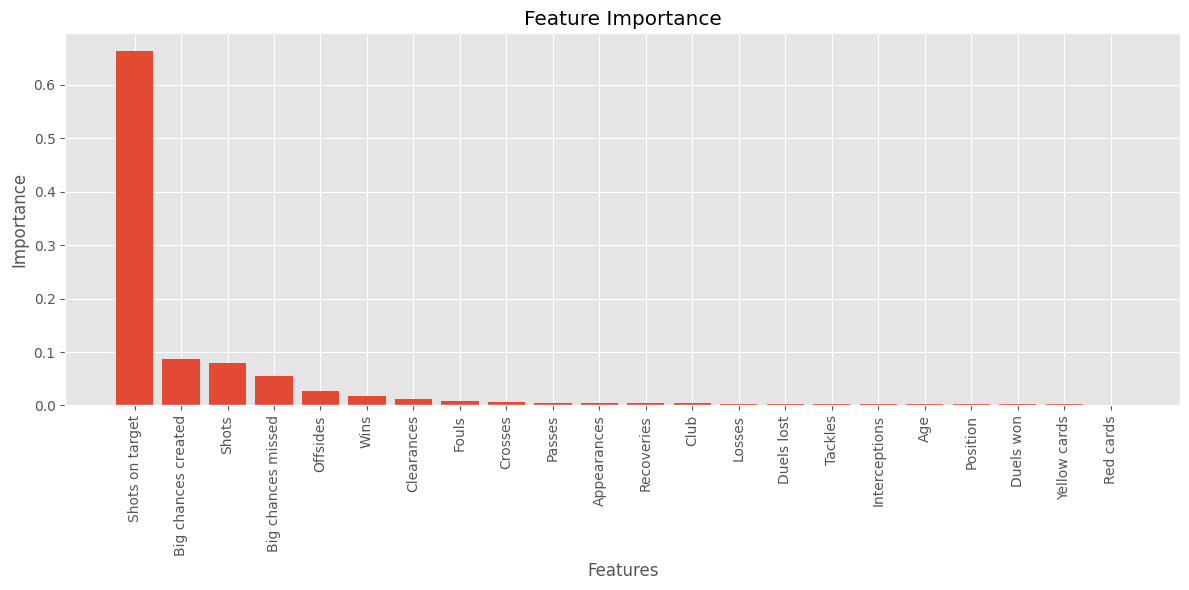

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

# Actual vs Predicted Goals

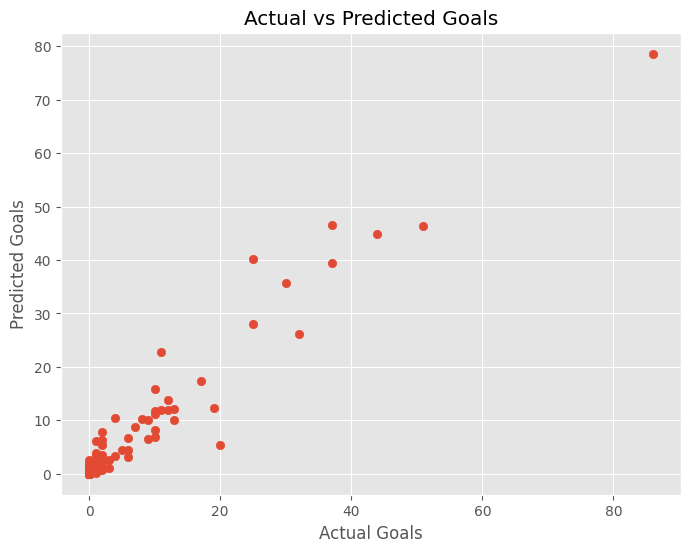

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test["Goals"],
    predictions[:,0]
)

plt.xlabel("Actual Goals")

plt.ylabel("Predicted Goals")

plt.title("Actual vs Predicted Goals")

plt.grid(True)

plt.show()

# Actual vs Predicted Assists

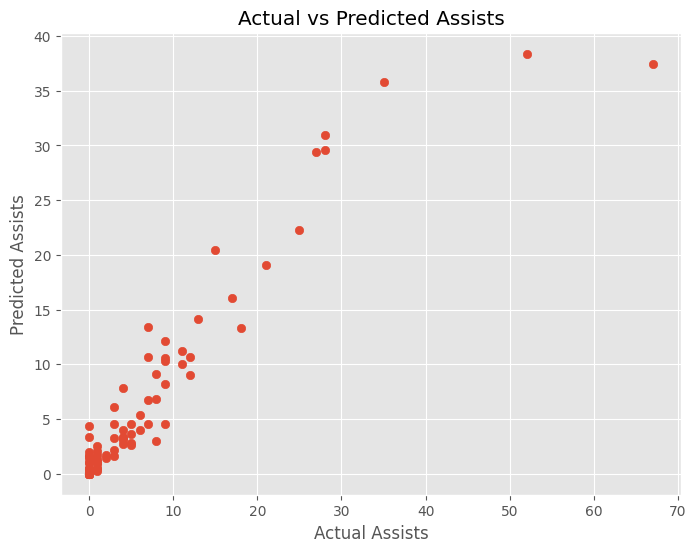

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test["Assists"],
    predictions[:,1]
)

plt.xlabel("Actual Assists")

plt.ylabel("Predicted Assists")

plt.title("Actual vs Predicted Assists")

plt.grid(True)

plt.show()

# Save Model Files

In [ ]:
import joblib

joblib.dump(
    model,
    "player_prediction_model.pkl"
)

joblib.dump(
    club_encoder,
    "club_encoder.pkl"
)

joblib.dump(
    position_encoder,
    "position_encoder.pkl"
)

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "player_feature_columns.pkl"
)

player_df.to_csv(
    "player_stats.csv",
    index=False
)

print("All files saved successfully.")

All files saved successfully.


# Download Files

In [ ]:
from google.colab import files

files.download("player_prediction_model.pkl")
files.download("club_encoder.pkl")
files.download("position_encoder.pkl")
files.download("player_feature_columns.pkl")
files.download("player_stats.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>